In [1]:
import random

# Check GC content
def calculate_gc_content(seq):
    gc_count = seq.count('G') + seq.count('C')
    return gc_count / len(seq)

def generate_synthetic_sequences(n_samples=1000,high_fraction=0.40, low_fraction=0.40, boundary_fraction=0.20):
    """
    Generate synthetic DNA sequences with a controlled proportion of GC classes.
    - high_fraction: fraction of samples generated with >60% GC (label=1)
    - low_fraction:  fraction of samples generated with <40% GC (label=0)
    - boundary_fraction: fraction near 50% GC (label assigned by GC threshold)
    Returns:
        sequences: List[str]
        labels: List[int]
    """
    # Normalize fractions if they don't sum to 1
    total = high_fraction + low_fraction + boundary_fraction
    high_fraction /= total
    low_fraction /= total
    boundary_fraction /= total

    n_high = int(n_samples * high_fraction)
    n_low = int(n_samples * low_fraction)
    n_boundary = n_samples - n_high - n_low

    sequences = []
    labels = []

    for _ in range(n_high):
        sequences.append(generate_high_gc_sequence(random.choice([50, 100, 150,200,250])))
        labels.append(1)

    for _ in range(n_low):
        sequences.append(generate_low_gc_sequence(random.choice([50, 100, 150,200,250])))
        labels.append(0)

    for _ in range(n_boundary):
        seq = boundary_sequence(random.choice([50, 100, 150,200,250]))
        sequences.append(seq)
        labels.append(1 if calculate_gc_content(seq) > 0.5 else 0)

    # Shuffle while keeping sequences/labels aligned
    combined = list(zip(sequences, labels))
    random.shuffle(combined)
    sequences, labels = zip(*combined)

    return list(sequences), list(labels)

def generate_high_gc_sequence(seq_length, min_gc=0.6, max_gc=0.9):
    """Generate sequence with GC fraction sampled uniformly in [min_gc, max_gc]."""
    target_frac = random.uniform(min_gc, max_gc)
    target_gc = int(round(seq_length * target_frac))
    gc_positions = set(random.sample(range(seq_length), target_gc))

    seq = []
    for i in range(seq_length):
        if i in gc_positions:
            seq.append(random.choice(['G', 'C']))
        else:
            seq.append(random.choice(['A', 'T']))
    return ''.join(seq)

def generate_low_gc_sequence(seq_length, min_gc=0.1, max_gc=0.4):
    """Generate sequence with GC fraction sampled uniformly in [min_gc, max_gc]."""
    target_frac = random.uniform(min_gc, max_gc)
    target_gc = int(round(seq_length * target_frac))
    gc_positions = set(random.sample(range(seq_length), target_gc))

    seq = []
    for i in range(seq_length):
        if i in gc_positions:
            seq.append(random.choice(['G', 'C']))
        else:
            seq.append(random.choice(['A', 'T']))
    return ''.join(seq)   

def boundary_sequence(seq_length):
    """Generate sequence with GC fraction sampled uniformly in [0.4, 0.6]."""
    target_frac = random.uniform(0.4, 0.6)
    target_gc = int(round(seq_length * target_frac))
    gc_positions = set(random.sample(range(seq_length), target_gc))

    seq = []
    for i in range(seq_length):
        if i in gc_positions:
            seq.append(random.choice(['G', 'C']))
        else:
            seq.append(random.choice(['A', 'T']))
    return ''.join(seq)

In [2]:
sequences, labels = generate_synthetic_sequences(n_samples=1000,high_fraction=0.40, low_fraction=0.40, boundary_fraction=0.20)

print("\nFirst 5 sequences:")
for i in range(5):
    gc = calculate_gc_content(sequences[i])
    print(f"  {sequences[i]} → label={labels[i]} (GC={gc:.1%}) {len(sequences[i])}bp")

print(f"Boundary GC content sequences: {sum(1 for gc in [calculate_gc_content(seq) for seq in sequences] if 0.45 <= gc <= 0.55)}")


First 5 sequences:
  ATTATCATATTCATCGACTTAAATATAAAATCTAATTATCTTTAACATAATACCTTTAATATAATTCATCAGTAATAATATTTTAAATGATTCTAATGTTAATTCAAACTAAGTTTCATAATCTTTTTATTATATTAAAATTTTTAAAAAATGTTATATCTATTATTATTATAAATAAAGTTAAAAATTAGATTATTTAT → label=0 (GC=12.5%) 200bp
  ATTTTTAAGGACAGAAAAAGAAAAAAAATTTTAGATCTATATTATTTTATTAATCTTTACAGGAAATAGCTGTTACTTTTGCATACAATGATATATTAAAAGTTATATTATAATGGATAATTCTTAATAAATTTTTGATAATTTCGGAAACGTATAATTATGATTACTTTATATATAAAAATAAGCAAATTATTTGTACACATCGATACGATAAATTATAAAGATTTATGATCAGTATCTTAAATTATGT → label=0 (GC=18.4%) 250bp
  TGACATCAATGTAGGTCGCTACATCGAGAGACAGAACTAATCGTCTGACCAAGGCCCCAGACTACATAAAAGTCCACGTGAGCGATACTCTAAAATAGGGACGTAACATCAAAAGACTTTCACCCCAGTTCTGATGGCACACCTCGACACCACCAAAAGAGAGCGTCTGTTGCCTTGGGTCGGGACAGGCAGAGTTTGAT → label=0 (GC=48.5%) 200bp
  TCCCGAGGAACCCCGGCTGCTGGGGTGCCCGGCCATTGGTATAGATCTCTTGGTTCTGGACGGCGGGCTGCGCCGGGCACACGGGGGGCCTCAGGGGTAA → label=1 (GC=69.0%) 100bp
  GCTGTGGACCGCACCGCCCGCGGCCAGCCGCCGGCGCGGGCGGCCGCCGACCCCGCTCCGCCGCTCGGTCCCGTGCTGGGGCGCCCCGGCGGTCCGACGGCGTGGCGG

In [3]:
#Import sequence one-hot encoder and encode sequences

import sys
import torch

sys.path.append('../../week2_pytorch-genomics-fundamentals/src/')

from SequenceEncoder import SequenceEncoder

encoder = SequenceEncoder()

encoded_sequences = []

for seq in sequences:
    encoded_seq = encoder.encode(seq)
    #flattened_seq = encoded_seq.flatten()
    encoded_seq_t = encoded_seq.T  # Transpose to shape (4, sequence_length) to match Conv1d input format
    encoded_sequences.append(encoded_seq_t)


In [4]:
y = torch.tensor(labels, dtype=torch.float32).unsqueeze(-1)

print(f"Labels shape: {y.shape}")

Labels shape: torch.Size([1000, 1])


In [6]:
# Part 3: Training Components
import torch.nn as nn
import torch.optim as optim
from models import SimpleDNAClassifier

# Create model
model = SimpleDNAClassifier(input_size=4, hidden_size=64, output_size=1)
print(model)

# Loss function
criterion = nn.BCELoss()

# Optimizer  
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("\n✅ Ready to train!")

SimpleDNAClassifier(
  (fc1): Conv1d(4, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (relu): ReLU()
  (fc2): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
  (global_pool): AdaptiveAvgPool1d(output_size=1)
  (fc3): Linear(in_features=128, out_features=1, bias=True)
  (pred): Sigmoid()
)

✅ Ready to train!


In [22]:
sys.path.append('../src/')
from data_utils import DNADataset
from torch.utils.data import DataLoader



# Training configuration
num_epochs = 100
train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

from sklearn.model_selection import train_test_split

# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    encoded_sequences, y, test_size=0.2, random_state=42, stratify=y
)

train_dataset = DNADataset(X_train, y_train)
test_dataset = DNADataset(X_test, y_test)

# Use it in DataLoader
train_dataloader = DataLoader(train_dataset, batch_size=32, collate_fn=data_utils.collate_variable_length)
test_dataloader = DataLoader(test_dataset, batch_size=32, collate_fn=data_utils.collate_variable_length)
print("Starting training...\n")

for epoch in range(num_epochs):
    # ========== TRAINING MODE ==========
    model.train()  # Set model to training mode
        
    for X_batch, y_batch in train_dataloader:
        # Forward pass
        train_predictions = model(X_batch)
        train_loss = criterion(train_predictions, y_batch)
        
        # Backward pass
        optimizer.zero_grad()  # Clear old gradients
        train_loss.backward()  # Calculate new gradients
        optimizer.step()       # Update parameters (weight -= lr * grad)
    
        # Calculate training accuracy
        train_pred_labels = (train_predictions > 0.5).float()
        train_acc = (train_pred_labels == y_batch).float().mean().item()
    
        # ========== EVALUATION MODE ==========
        model.eval()  # Set model to evaluation mode
        for X_test, y_test in test_dataloader:
            with torch.no_grad():  # Don't calculate gradients for evaluation
                test_predictions = model(X_test)
                test_loss = criterion(test_predictions, y_test)
            
            # Calculate test accuracy
            test_pred_labels = (test_predictions > 0.5).float()
            test_acc = (test_pred_labels == y_test).float().mean().item()
    
    # Track metrics
    train_losses.append(train_loss.item())
    test_losses.append(test_loss.item())
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    
    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"  Train Loss: {train_loss.item():.4f}, Train Acc: {train_acc:.2%}")
        print(f"  Test Loss: {test_loss.item():.4f}, Test Acc: {test_acc:.2%}")
        print()

print(f"\nFinal Results:")
print(f"  Final accuracy: {test_acc:.2%}")
print(f"  Train Loss: {train_loss.item():.4f}, Train Acc: {train_acc:.2%}")
print(f"  Test Loss: {test_loss.item():.4f}, Test Acc: {test_acc:.2%}")

SyntaxError: invalid syntax (1005088216.py, line 2)

In [10]:
# Create some test sequences
test_sequences = []

for _ in range(50):
    seq = generate_high_gc_sequence(random.choice([100, 150, 200,500]), min_gc=0.5, max_gc=0.9) if random.random() < 0.5 else generate_low_gc_sequence(random.choice([100, 150, 200,500]), min_gc=0.1, max_gc=0.5)
    test_sequences.append(seq)

print("Testing model on new sequences:\n")

#model = SimpleDNAClassifier(input_size=4, hidden_size=64, output_size=1, seq_length=100)
model.eval()
with torch.no_grad():
    for seq in test_sequences:
        # Encode the sequence
        encoded = encoder.encode(seq)
        
        # Get prediction
        testdata = torch.tensor(encoded.T, dtype=torch.float32).unsqueeze(0)  # Shape (1, 4, seq_length)
        prob = model(testdata).item()
        prediction = 1 if prob > 0.5 else 0
        
        # Calculate actual GC content
        gc_content = (seq.count('G') + seq.count('C')) / len(seq)
        
        # Display results
        print(f"Sequence: {seq}")
        print(f"  GC content: {gc_content:.1%}")
        print(f"  Predicted probability: {prob:.4f}")
        print(f"  Predicted class: {prediction} ({'Coding' if prediction == 1 else 'Non-coding'})")
        print(f"  Confidence: {'High' if abs(prob - 0.5) > 0.4 else 'Medium'}")
        print()

Testing model on new sequences:

Sequence: ACGACGGCCATTCTACCGCAGCTCCTCCGTGGCCTCATACCAGTCGAAGGATATGTGGCACGCCCGTCCTTACATTGCCGACAGGCCCGGCGTCAGGAATAAGAGTACATCGTGCAGTCTCGCCAGCGCCGCTGGAATCTGAGTCGATAGGGCCCTGTCAAGCACCACTCGAGTATAGGGCCGACTACAACGGGTAGTTC
  GC content: 59.0%
  Predicted probability: 1.0000
  Predicted class: 1 (Coding)
  Confidence: High

Sequence: ACGGTCACCACCCCAGCGTCTGATGGCCCCCCGGGGGCGCCACCAGTCTTGACACGCCCCGGCGTCGCGATGGTGAGGGTTTGCGTACACGGGGGCGTACGGCCATCTGCAAAGCCATCTAGGCAGAGTCGTTTAGTAGCGTAATCAGAGCCGCGATACGCGCAGTCTCGTGCCTGCCTCGCGCGCGCGCTCGAGGCTGG
  GC content: 67.0%
  Predicted probability: 1.0000
  Predicted class: 1 (Coding)
  Confidence: High

Sequence: ATTTAAAATTAGTTAATTTAGATTAATAAATATTCTACATTGTATTAAAAATATACATTTTATATAGATTTATTGGCGTTGGACATATATGATAATGAATAAAATATTACTTTATAAAAATATTAATATTCATTGAACATAAGTTATGCAACACATGCTATTAATACAGTTACTAATTGTGATTTAATCTTTGAATTCTG
  GC content: 18.0%
  Predicted probability: 0.0000
  Predicted class: 0 (Non-coding)
  Confidence: High

Sequence: TATGAATTATATTT

C:\Users\kudakwasheN\AppData\Local\Temp\ipykernel_47716\4164296301.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  testdata = torch.tensor(encoded.T, dtype=torch.float32).unsqueeze(0)  # Shape (1, 4, seq_length)


In [14]:
len(test_sequences)

50

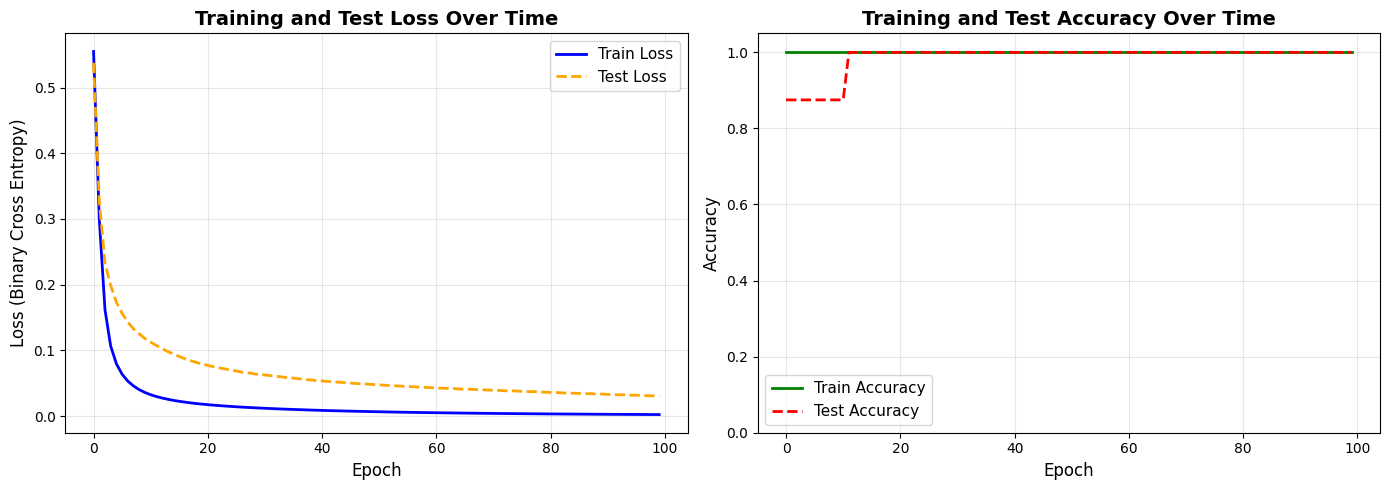

✅ Training curves saved as 'training_curves.png'


In [11]:
import matplotlib.pyplot as plt

# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss curves
axes[0].plot(train_losses, label='Train Loss', linewidth=2, color='blue')
axes[0].plot(test_losses, label='Test Loss', linewidth=2, linestyle='--', color='orange')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss (Binary Cross Entropy)', fontsize=12)
axes[0].set_title('Training and Test Loss Over Time', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Plot 2: Accuracy curves  
axes[1].plot(train_accuracies, label='Train Accuracy', linewidth=2, color='green')
axes[1].plot(test_accuracies, label='Test Accuracy', linewidth=2, linestyle='--', color='red')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Training and Test Accuracy Over Time', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig('training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Training curves saved as 'training_curves.png'")

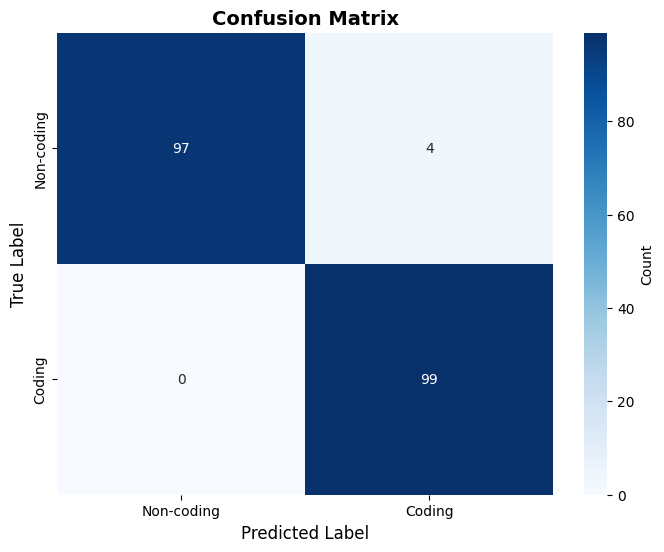


📊 Classification Report:
              precision    recall  f1-score   support

  Non-coding     1.0000    0.9604    0.9798       101
      Coding     0.9612    1.0000    0.9802        99

    accuracy                         0.9800       200
   macro avg     0.9806    0.9802    0.9800       200
weighted avg     0.9808    0.9800    0.9800       200


📈 Detailed Metrics:
True Negatives (TN): 97
False Positives (FP): 4
False Negatives (FN): 0
True Positives (TP): 99

Precision: 0.9612 (of predicted coding, how many were actually coding)
Recall: 1.0000 (of actual coding, how many did we find)
F1-Score: 0.9802 (harmonic mean of precision and recall)


In [18]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Get predictions on test set
model.eval()
test_predictions = []
test_labels = []
for X_test, y_test in test_dataloader:
    with torch.no_grad():
        test_predictions.append(model(X_test))
        test_labels.append(y_test)
# Convert to numpy for sklearn
y_test_np = np.concatenate([y.cpu().numpy().flatten() for y in test_labels])
y_pred_np = np.concatenate([pred.cpu().numpy().flatten() > 0.5 for pred in test_predictions])

# Confusion Matrix
cm = confusion_matrix(y_test_np, y_pred_np)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-coding', 'Coding'],
            yticklabels=['Non-coding', 'Coding'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Classification Report
print("\n📊 Classification Report:")
print("="*50)
report = classification_report(y_test_np, y_pred_np, 
                               target_names=['Non-coding', 'Coding'],
                               digits=4)
print(report)

# Manual calculation to understand metrics
tn, fp, fn, tp = cm.ravel()
print("\n📈 Detailed Metrics:")
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")
print(f"\nPrecision: {tp/(tp+fp):.4f} (of predicted coding, how many were actually coding)")
print(f"Recall: {tp/(tp+fn):.4f} (of actual coding, how many did we find)")
print(f"F1-Score: {2*tp/(2*tp+fp+fn):.4f} (harmonic mean of precision and recall)")

In [17]:
len(y_test)

8

In [9]:
import os

# Create models directory
os.makedirs('saved_models', exist_ok=True)

# Save model state
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'train_loss': train_losses[-1],
    'test_loss': test_losses[-1],
    'train_accuracy': train_accuracies[-1],
    'test_accuracy': test_accuracies[-1],
    'epoch': num_epochs,
    'model_config': {
        'input_size': 4,
        'hidden_size': 64,
        'output_size': 1
    }
}, 'saved_models/dna_cnn_classifier.pth')

print("✅ Model saved to 'saved_models/dna_cnn_classifier.pth'")

✅ Model saved to 'saved_models/dna_cnn_classifier.pth'
